# Responsible AI: Age Classification System

#### Training Data: UTKFace | Fairness Testing: FairFace
#### Goal: Build a race-agnostic age classifier for retail analytics



In [23]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")

All libraries imported successfully


In [24]:
BASE = Path.home() / "Downloads" / "responsible ai"

# UTKFace — for training
UTK_DIR = BASE / "archive" / "UTKFace"

# FairFace — for fairness testing only
FAIRFACE_TRAIN = BASE / "FairFace Race" / "train"
FAIRFACE_VAL   = BASE / "FairFace Race" / "val"

print("UTKFace exists  :", UTK_DIR.exists())
print("FairFace exists :", FAIRFACE_TRAIN.exists())

UTKFace exists  : True
FairFace exists : True



##  Data Loading


###  Load UTKFace

In [25]:
RACE_MAP   = {0: "White", 1: "Black", 2: "Asian", 3: "Indian", 4: "Other"}
GENDER_MAP = {0: "Male",  1: "Female"}

rows    = []
skipped = 0

for img in UTK_DIR.iterdir():
    if not img.name.endswith(".jpg"):
        skipped += 1
        continue
    parts = img.stem.split("_")
    if len(parts) < 3:
        skipped += 1
        continue
    try:
        rows.append({
            "filepath" : str(img),
            "age"      : int(parts[0]),
            "gender"   : GENDER_MAP.get(int(parts[1]), "Unknown"),
            "race"     : RACE_MAP.get(int(parts[2]),   "Unknown"),
        })
    except ValueError:
        skipped += 1

df_utk = pd.DataFrame(rows)

print("UTKFace loaded :", len(df_utk), "images")
print("Skipped        :", skipped)
df_utk.head(3)

UTKFace loaded : 23705 images
Skipped        : 3


,filepath,age,gender,race
0,/Users/namratabhoyar/Downloads/responsible ai/...,9,Female,Asian
1,/Users/namratabhoyar/Downloads/responsible ai/...,36,Male,Black
2,/Users/namratabhoyar/Downloads/responsible ai/...,86,Female,White


### Load FairFace

In [26]:
rows = []

for race_folder in FAIRFACE_TRAIN.iterdir():
    for img in race_folder.glob("*.jpg"):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "train"})

for race_folder in FAIRFACE_VAL.iterdir():
    for img in race_folder.glob("*.jpg"):
        rows.append({"filepath": str(img), "race": race_folder.name, "split": "val"})

df_fairface = pd.DataFrame(rows)

print("FairFace loaded :", len(df_fairface), "images")
print("Races           :", sorted(df_fairface["race"].unique()))
df_fairface.head(3)

FairFace loaded : 97698 images
Races           : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']


,filepath,race,split
0,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train
1,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train
2,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train


## Data Cleaning & Privacy



### Clean UTKFace

In [27]:
df_utk_clean = df_utk.copy()

# Step 1: Remove extreme ages
df_utk_clean = df_utk_clean[df_utk_clean["age"] >= 1]
df_utk_clean = df_utk_clean[df_utk_clean["age"] <= 100]

# Step 2: Remove unknown gender
df_utk_clean = df_utk_clean[df_utk_clean["gender"] != "Unknown"]

# Step 3: Remove nulls
df_utk_clean = df_utk_clean.dropna(subset=["age", "gender", "race"])

# Step 4: Verify files exist on disk
df_utk_clean["exists"] = df_utk_clean["filepath"].apply(os.path.exists)
df_utk_clean = df_utk_clean[df_utk_clean["exists"]].drop(columns=["exists"])

# Step 5: Flag minors
df_utk_clean["is_minor"] = df_utk_clean["age"] < 18

print("UTKFace after cleaning :", len(df_utk_clean))
print("Minors (age < 18)      :", df_utk_clean["is_minor"].sum())
print("Adults                 :", (~df_utk_clean["is_minor"]).sum())
df_utk_clean.head(3)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
UTKFace after cleaning : 23684
Minors (age < 18)      : 4233
Adults                 : 19451


,filepath,age,gender,race,is_minor
0,/Users/namratabhoyar/Downloads/responsible ai/...,9,Female,Asian,True
1,/Users/namratabhoyar/Downloads/responsible ai/...,36,Male,Black,False
2,/Users/namratabhoyar/Downloads/responsible ai/...,86,Female,White,False


### Clean FairFace

In [28]:
df_fairface_clean = df_fairface.copy()

# Step 1: Verify files exist on disk
df_fairface_clean["exists"] = df_fairface_clean["filepath"].apply(os.path.exists)
df_fairface_clean = df_fairface_clean[df_fairface_clean["exists"]].drop(columns=["exists"])

# Step 2: Remove nulls
df_fairface_clean = df_fairface_clean.dropna(subset=["race"])

# Step 3: Keep only needed columns
df_fairface_clean = df_fairface_clean[["filepath", "race", "split"]]

print("FairFace after cleaning :", len(df_fairface_clean))
print("Races :", sorted(df_fairface_clean["race"].unique()))
df_fairface_clean.head(3)

FairFace after cleaning : 97698
Races : ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']


,filepath,race,split
0,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train
1,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train
2,/Users/namratabhoyar/Downloads/responsible ai/...,Indian,train


### Add Age Groups to UTKFace

In [29]:
def age_to_group(age):
    if   age <= 2:  return "0-2"
    elif age <= 9:  return "3-9"
    elif age <= 19: return "10-19"
    elif age <= 29: return "20-29"
    elif age <= 39: return "30-39"
    elif age <= 49: return "40-49"
    elif age <= 59: return "50-59"
    elif age <= 69: return "60-69"
    else:           return "70+"

df_utk_clean["age_group"] = df_utk_clean["age"].apply(age_to_group)

print("Age groups created:")
print(df_utk_clean["age_group"].value_counts().sort_index())

Age groups created:
age_group
0-2      1605
10-19    1531
20-29    7344
3-9      1457
30-39    4536
40-49    2245
50-59    2299
60-69    1316
70+      1351
Name: count, dtype: int64


### Cleaning Decisions & Privacy Rationale

| Step | Decision | Reason |
|---|---|---|
| 1 | Removed ages < 1 and > 100 | Likely annotation errors |
| 2 | Removed Unknown gender | Cannot use for fairness testing |
| 3 | Removed null rows | Data integrity |
| 4 | Verified files on disk | No broken records in pipeline |
| 5 | Flagged minors (age < 18) | GDPR Article 8: children need special protection |
| 6 | Kept race for bias audit only | Race is NEVER a model input |
| 7 | Dropped Adience dataset | Too small, no race labels, rough age brackets only |

**UTKFace → Model Training**
**FairFace → Fairness Testing only**

## Exploratory Data Analysis (EDA)

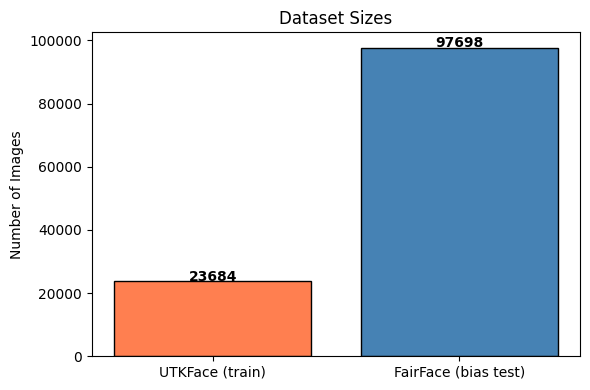

In [30]:
counts = {"UTKFace (train)": len(df_utk_clean),
          "FairFace (bias test)": len(df_fairface_clean)}

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=["coral", "steelblue"], edgecolor="black")
plt.title("Dataset Sizes")
plt.ylabel("Number of Images")
for i, v in enumerate(counts.values()):
    plt.text(i, v + 100, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

###  UTKFace Age Distribution

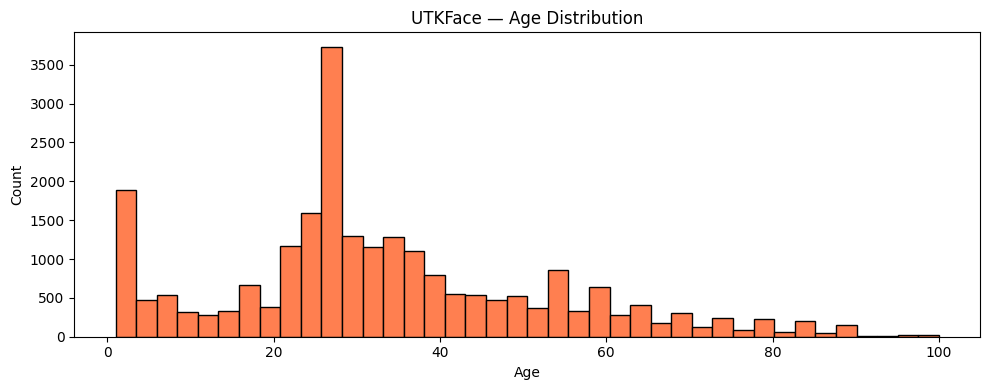

Min age : 1
Max age : 100
Mean age: 33.2


In [31]:
plt.figure(figsize=(10, 4))
plt.hist(df_utk_clean["age"], bins=40, color="coral", edgecolor="black")
plt.title("UTKFace — Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Min age :", df_utk_clean["age"].min())
print("Max age :", df_utk_clean["age"].max())
print("Mean age:", round(df_utk_clean["age"].mean(), 1))

### UTKFace Age Group Distribution

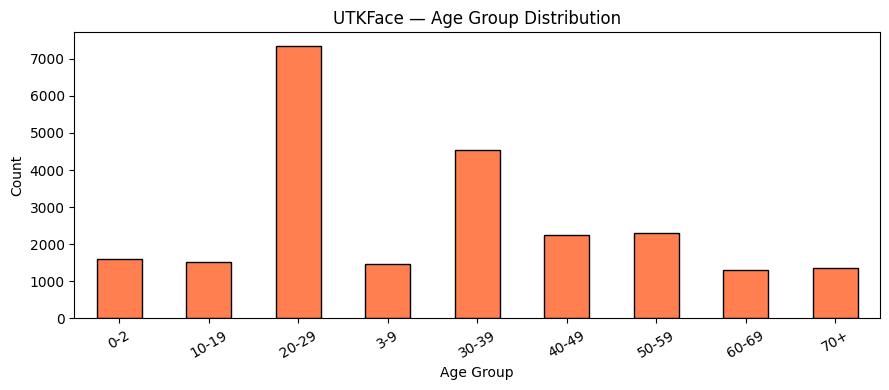

In [32]:
plt.figure(figsize=(9, 4))
df_utk_clean["age_group"].value_counts().sort_index().plot(
    kind="bar", color="coral", edgecolor="black"
)
plt.title("UTKFace — Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### UTKFace Race Distribution

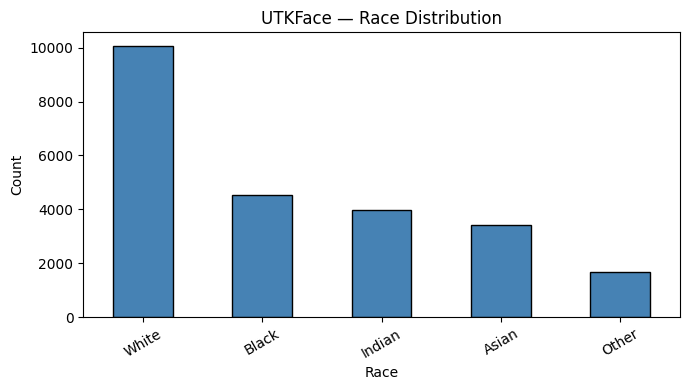

In [33]:
plt.figure(figsize=(7, 4))
df_utk_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("UTKFace — Race Distribution")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### UTKFace Gender Distribution

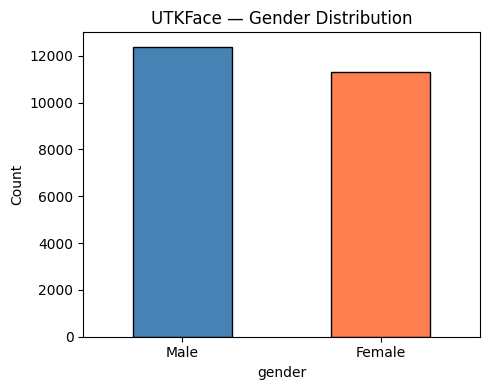

In [34]:
plt.figure(figsize=(5, 4))
df_utk_clean["gender"].value_counts().plot(
    kind="bar", color=["steelblue", "coral"], edgecolor="black"
)
plt.title("UTKFace — Gender Distribution")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### FairFace Race Distribution

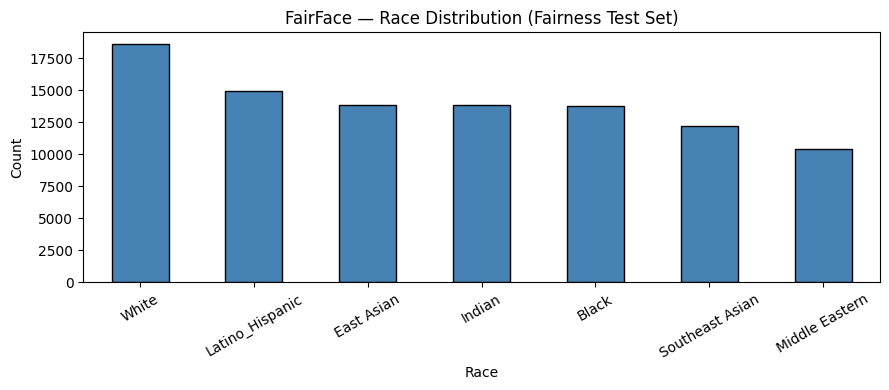

In [36]:
plt.figure(figsize=(9, 4))
df_fairface_clean["race"].value_counts().plot(
    kind="bar", color="steelblue", edgecolor="black"
)
plt.title("FairFace — Race Distribution (Fairness Test Set)")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Bias Check: Age by Race

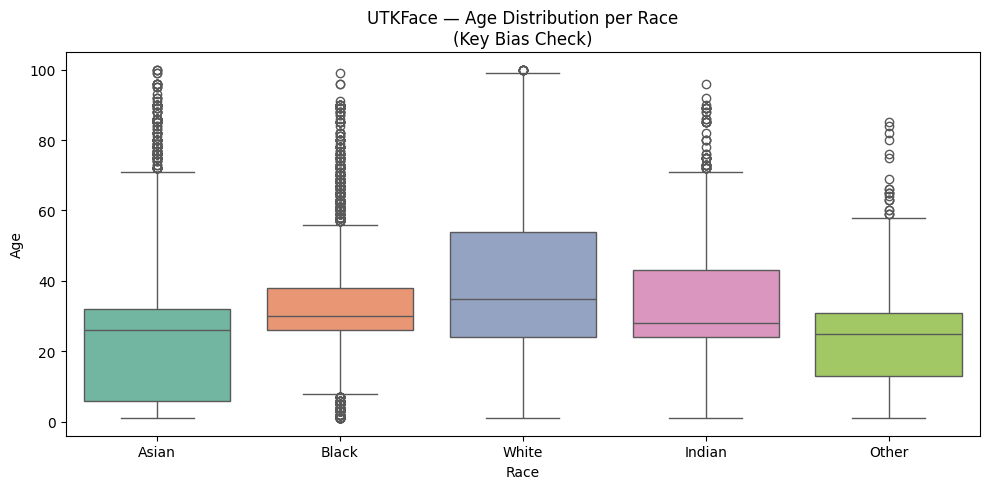

In [37]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_utk_clean, x="race", y="age", palette="Set2")
plt.title("UTKFace — Age Distribution per Race\n(Key Bias Check)")
plt.xlabel("Race")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

## Sample Images

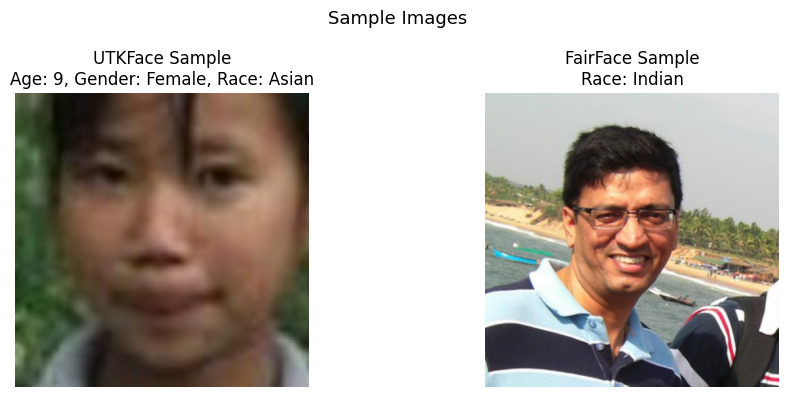

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

img1 = mpimg.imread(df_utk_clean["filepath"].iloc[0])
axes[0].imshow(img1)
axes[0].set_title(f"UTKFace Sample\nAge: {df_utk_clean['age'].iloc[0]}, "
                  f"Gender: {df_utk_clean['gender'].iloc[0]}, "
                  f"Race: {df_utk_clean['race'].iloc[0]}")
axes[0].axis("off")

img2 = mpimg.imread(df_fairface_clean["filepath"].iloc[0])
axes[1].imshow(img2)
axes[1].set_title(f"FairFace Sample\nRace: {df_fairface_clean['race'].iloc[0]}")
axes[1].axis("off")

plt.suptitle("Sample Images", fontsize=13)
plt.tight_layout()
plt.show()

## EDA Summary (Markdown)

### EDA Key Findings

| Finding | Impact on Model |
|---|---|
| Young faces (20-30) dominate UTKFace | Model may underperform on elderly |
| White faces outnumber others in UTKFace | Potential accuracy gap for other races |
| FairFace balanced across 7 races | Good fairness test set |
| Minors present in UTKFace | Documented — special care in deployment |
| Age 70+ very underrepresented | Use class weights during training |

**Next Step → Model Building on UTKFace**